# Exercise 4b

Deadline 08.01.2026

Anna Bütfering

Lea Neumann

Juan Provencio



In [78]:
# Torch
import numpy as np 
print("Numpy version:", np.__version__)
import torch 
from torch.nn import functional as F
from torch import nn, optim
from torch import sqrt, exp
# Sklearn
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
# Etc.
import matplotlib.pyplot as plt
from tqdm import tqdm
## Plot options
from cycler import cycler
from matplotlib import rcParams
rcParams['axes.grid'] = True
rcParams['grid.linestyle'] = '--'
rcParams['grid.alpha'] = 0.5
rcParams['axes.labelsize'] = 20
rcParams['axes.prop_cycle'] = cycler('color', ['#C61A27', '#3891A6', \
                                               '#F79D65', '#FDE74C', \
                                                '#9BC53D', '#5BC0EB',
                                                '#E55934', '#FA7921',
                                                '#8D230F', '#1B998B'])
colors = rcParams['axes.prop_cycle'].by_key()['color']
rcParams['axes.titlesize'] = 22
rcParams['figure.figsize'] = (12, 7)
rcParams['figure.titlesize'] = 26
rcParams['font.size'] = 16
rcParams['image.cmap'] = 'magma'
rcParams['lines.markeredgewidth'] = 2
rcParams['lines.markerfacecolor'] = 'white'
rcParams['markers.fillstyle'] = 'none'
# Define textbox style for plots
textbox_style = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='black')

Numpy version: 1.26.4


## Validation

 # [FIRST WE TRIED PROVIDING OUR OWN SOLUTION TO THE PREVIOUS EXERCISE, BUT WE DIDN'T GET THE NETWORK TO WORK CORRECTLY, SO WE COPIED THE SAMPLE SOLUTION IN ORDER TO BE ABLE TO MOVE ON WITH THE EXERCISE]

Since we didn't finish task 3 in the previous exercise, we will do so now but with the help of specialized libraries. The goal is to program a conditional invertible network (cINN) to predict the full posterior $p(Y|x)$ with the help of a summary network $h(x)$ to reduce the dimensionality of the 200-dimensional vector. As a basis for the summary network, we will use our best model for $\Phi(x)$ from exercise 4a and modify it accordingly by dropping the last layer.

Then, we drop the training method from the network class, as it will now be trained jointly with the cINN with a RealNVP

In [79]:
T = 100
N = 1000
R_0 = 0

# prior and simulation interfaces 
class Prior: 
    def __init__(self, prior_fn, labels): 
        self.prior_fn = prior_fn 
        self.labels = labels 
        self.mean = None 
        self.std = None 
        self.__set_stats__() 
     
    def __call__(self, n_samples, **kwargs): 
        return self.prior_fn(n_samples, **kwargs) 
     
    def get_labels(self): 
        return self.labels 
     
    def __set_stats__(self): 
        samples = self.prior_fn(10000) 
        self.mean = np.mean(samples, axis=0) 
        self.std = np.std(samples, axis=0) 
    
    def get_stats(self): 
        return self.mean, self.std
    
class Simulator: 
    def __init__(self, simulator_fn, prior): 
        self.simulator_fn = simulator_fn 
        self.labels = ['dS', 'dR'] 
        self.C = ['S', 'I', 'R'] 
        self.mean = None 
        self.std = None 
        self.__set_stats__(prior(10000)) 
     
    def __call__(self, prior_samples, return_C=False): 
        X, C = np.zeros((prior_samples.shape[0], T, len(self.labels))), np.zeros((prior_samples.shape[0], T, len(self.C))) 
        for i, p in enumerate(prior_samples): 
            X[i,...], C[i,...] = self.simulator_fn(*p) 
        if return_C: 
            return C 
        else: 
            return X 
     
    def get_labels(self): 
        return self.labels 
     
    def __set_stats__(self, prior_samples): 
        sim_samples = np.zeros((prior_samples.shape[0], T, len(self.labels))) 
        for i, p in enumerate(prior_samples): 
            sim_samples[i] = self.simulator_fn(*p)[0] 
        self.mean = np.mean(sim_samples, axis=0) 
        self.std = np.std(sim_samples, axis=0)     
     
    def get_stats(self): 
        return self.mean, self.std

def generate_data(n_data_points, prior, simulator): 
    prior_mean, prior_std = prior.get_stats() 
    sim_mean, sim_std = simulator.get_stats() 
 
    prior_samples = prior(n_data_points) 
    norm_prior_samples = (prior_samples - prior_mean) / prior_std 
 
    sir_observations = simulator(prior_samples) 
    # convert to channels first 
    norm_sir_observations = (sir_observations - sim_mean) / sim_std 
    norm_sir_observations = np.nan_to_num(norm_sir_observations) 
    norm_sir_observations = np.moveaxis(norm_sir_observations, -1, 1) 
 
    return norm_prior_samples, norm_sir_observations

def _deriv(input, N, lam, mu): 
    S, I, _ = input 
    dS = -lam * S * I / N 
    dI = lam * S * I / N - mu * I 
    dR = mu * I 
    return dS, dI, dR 
 
def simulate_sir_sample(lam, mu, I_0, T=T, N=N, R_0=R_0): 
    S, I, R = np.zeros(T), np.zeros(T), np.zeros(T) 
    dS, dI, dR = np.zeros(T), np.zeros(T), np.zeros(T) 
 
    # Initial conditions 
    S[0], I[0], R[0] = N - I_0 - R_0, I_0, R_0 
 
    for i in range(1, T): 
        dS[i], dI[i], dR[i] = _deriv((S[i-1], I[i-1], R[i-1]), N, lam, mu) 
        S[i], I[i], R[i] = S[i-1] + dS[i], I[i-1] + dI[i], R[i-1] + dR[i] 
 
    X = np.stack((dS, dR), axis=-1) 
    C = np.stack((S, I, R), axis=-1) 
 
    return X, C

# Summary network:
class SummaryNN(nn.Module):
    def __init__(self, layers_sizes=[128, 128], last_layer = True):
        super().__init__()

        self.losses = []
        # Ordinary Feed Forward Network Architecture with ReLU activations
        # Keep in mind, input is of size 100
        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(200, layers_sizes[0]))  # Input layer: 100 days * 2 features (delta S, delta R)
        # Hidden variables with variable sizes
        for i in range(len(layers_sizes) - 1):
            self.layers.append(nn.Linear(layers_sizes[i], layers_sizes[i+1]))
        if last_layer:
            self.output_layer = nn.Linear(layers_sizes[-1], 3)  # Output: lam, mu, I_0

    def forward(self, X):
        for layer in self.layers:
            X = F.relu(layer(X))
        if hasattr(self, 'output_layer'):
            X = self.output_layer(X)
        return X  
    
# Generate training data
def generate_training_data(n_samples, T):
    X_train = []
    y_train = []
    for _ in range(n_samples):
        # Sample from prior
        lam = np.random.uniform(0.1, 0.4)
        mu = np.random.uniform(0.05, 0.25)
        I_0 = np.random.uniform(0.05, 0.4)
        # Simulate SIR
        x, c = simulate_sir_sample(lam, mu, I_0, T)
        X_train.append(np.array(x).flatten())
        y_train.append([lam, mu, I_0])
    X_train = torch.tensor(X_train, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.float32)
    return X_train, y_train

In [80]:
# Prepare data
X_train, y_train = generate_training_data(n_samples=10000, T=100)
X_val, y_val = generate_training_data(n_samples=2500, T=100)

We use the FrEIA (Framework for Easily Invertible Architectures) in python to create our cINN:

In [81]:
import FrEIA.framework as ff
import FrEIA.modules as fm

def build_cinn(params_dim = 3, summary_dim = 32, dropout_rate = 0.0):
    # Define DenseNet: 
    # internal, fully connected, not invertible network for coupling layers
    def dense_net(dims_in, dims_out):
        if dropout_rate > 0.0:
            return nn.Sequential(nn.Linear(dims_in, 512),
                                 nn.ReLU(),
                                 nn.Dropout(dropout_rate),
                                 nn.Linear(512, dims_out))
        else: 
            return nn.Sequential(nn.Linear(dims_in, 512),
                                nn.ReLU(),
                                nn.Linear(512, dims_out))
    
    # Define cINN architecture
    inn = ff.SequenceINN(params_dim)
    for k in range(8): # 8 coupling layers like in the example solution
        inn.append(fm.AllInOneBlock, 
                   cond=0,
                   subnet_constructor=dense_net,
                   cond_shape=(summary_dim,),
                   permute_soft=True)
        
    return inn

# Loss functions (copied from sample solution)
def nll_loss_gaussian(z, log_det_J): 
    """ 
    Computes the Kullback-Leibler divergence between the true and approximate 
    posterior assuming a Gaussian latent space as a source distribution. 
    """ 
    loss = torch.mean(0.5 * torch.square(torch.norm(z, dim=-1)) - log_det_J) 
    return loss

# MMD loss (copied from sample solution)
def kernel(X, Y, sigma, reduce_mean=True): 
    mat = X[:,None]-Y 
    mat = mat**2 
    mat = -mat/((float(sigma)**2) * 2) 
    mat = torch.exp(mat) 
    if reduce_mean: 
        mat = torch.mean(mat) 
    return mat

def compute_mmd(X, Y, sigma=[0.1, 0.5, 1, 2, 5]): 
    if isinstance(sigma, (int, float)): 
        return torch.sqrt(torch.abs(kernel(X, X, sigma) + kernel(Y, Y, sigma) - 2. * kernel(X, Y, sigma
))) 
    elif isinstance(sigma, list): 
        total_mmd = 0 
        for kernel_size in sigma: 
            total_mmd += compute_mmd(X, Y, kernel_size) 
        return total_mmd

In [87]:
# Setup
dataloader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X_train, y_train), 
                                         batch_size=512, 
                                         shuffle=True)
dataloader_val = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X_val, y_val),
                                             batch_size=512,
                                             shuffle=False)
summary_net = SummaryNN(layers_sizes=[512, 512], last_layer=False, )
inn = build_cinn(params_dim=3, summary_dim=512, dropout_rate=0.0)
optimizer = optim.Adam(list(summary_net.parameters()) + list(inn.parameters()), lr=0.0001)

# Training loop
def training_loop(mmd_factor = 0.0):
    loss_history = {"train": [], "validation": []}
    n_epochs = 1000
    # Training
    for epoch in tqdm(range(n_epochs)):
        epoch_loss = 0
        # Switch to training mode
        summary_net.train()
        inn.train()

        for X_batch, y_batch in dataloader:

            optimizer.zero_grad()
            # Get summary net output
            summary = summary_net(X_batch)
            # Forward pass through cINN
            z, log_jac_det = inn(y_batch, c=[summary])
            prior_samples = torch.randn_like(z)
            # Compute NLL Gaussian loss
            loss = nll_loss_gaussian(z, log_jac_det)
            # Compute MMD loss (if mmd_factor > 0)
            if mmd_factor > 0:
                loss += compute_mmd(z, prior_samples) * mmd_factor

            # Append to list
            loss_history["train"].append(loss.item())
            # Backpropagation
            loss.backward()
            # Clip gradients due to exploding gradients
            nn.utils.clip_grad_norm_(summary_net.parameters(), max_norm=1)
            optimizer.step()

        # Include validation loss to detect overfitting (Toggle to evaluation mode)
        summary_net.eval()
        inn.eval()
        with torch.no_grad():
            for X_val_batch, y_val_batch in dataloader_val:
                summary_val = summary_net(X_val_batch)
                z_val, log_jac_det_val = inn(y_val_batch, c=[summary_val])
                prior_samples_val = torch.randn_like(z_val)
                val_loss = nll_loss_gaussian(z_val, log_jac_det_val)
                if mmd_factor > 0:
                    val_loss += compute_mmd(z_val, prior_samples_val) * mmd_factor
                loss_history["validation"].append(val_loss)

    
    return loss_history, summary_net, inn

loss_history_our, summary_net_our, inn_our = training_loop()

100%|██████████| 1000/1000 [45:42<00:00,  2.74s/it]


In [88]:
summary_net_our

SummaryNN(
  (layers): ModuleList(
    (0): Linear(in_features=200, out_features=512, bias=True)
    (1): Linear(in_features=512, out_features=512, bias=True)
  )
)

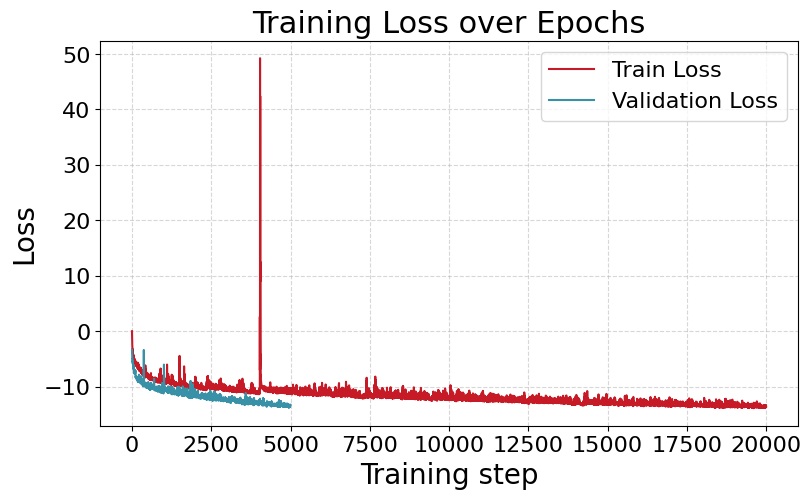

In [89]:
# Plot training loss
plt.figure(figsize=(9,5))
plt.plot(loss_history_our["train"], label = "Train Loss")
plt.plot(loss_history_our["validation"], label = "Validation Loss")
#plt.yscale('log')
plt.xlabel('Training step')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.legend()
plt.show()

We run the trained model on some test data generated by the simulation

In [90]:
# Define prior and simulator
prior = Prior(prior_fn=lambda n: np.column_stack((
    np.random.uniform(0.1, 0.4, size=n),  # lam
    np.random.uniform(0.05, 0.25, size=n),  # mu
    np.random.uniform(0.05, 0.4, size=n)  # I_0
)), labels=['lam', 'mu', 'I_0'])

simulator = Simulator(simulator_fn=simulate_sir_sample, prior=prior)

# Get test data function (adapted from sample solution)
def get_test_data(summary, inn, data_config, noise=0.0): 
    # Generate test data
    test_prior, test_sim = generate_data(data_config['n_test'], data_config['prior'], data_config['simulator']) 
    
    # Add noise to prior if specified
    test_prior = test_prior + np.random.normal(0, noise, size=test_prior.shape) 
    
    # Tensor conversion
    test_sim_tensor = torch.tensor(test_sim, dtype=torch.float32)
    test_prior_tensor = torch.tensor(test_prior, dtype=torch.float32)
    
    # Reshape from (batch, 2, 100) to (batch, 200) to match SummaryNN input 
    test_sim_tensor = test_sim_tensor.reshape(test_sim_tensor.shape[0], -1)
 
    summary.eval() 
    inn.eval() 
    
    with torch.no_grad():
        # Extract summary features h(x)
        conditions = summary(test_sim_tensor) 
        
        # Get latents (z) for ground truth parameters
        latents, _ = inn(test_prior_tensor, c=[conditions]) 
        
        # Sample from Posterior: draw z ~ N(0, I) and pass through inverse cINN
        n_samples = data_config['n_posterior_samples']
        n_test = data_config['n_test']
        param_dim = test_prior.shape[-1]
        
        post_samples = np.zeros((n_test, n_samples, param_dim)) 
        
        for i in range(n_samples): 
            z_rand = torch.randn_like(latents)
            samples, _ = inn(z_rand, c=[conditions], rev=True)
            post_samples[:, i, :] = samples.detach().cpu().numpy()
 
    # Unnormalize everything back to original parameter scales 
    prior_mean, prior_std = data_config['prior'].get_stats() 
    unnorm_prior = test_prior * prior_std + prior_mean 
    unnorm_post_samples = post_samples * prior_std + prior_mean 
    
    # Get raw SIR trajectories for visualization if needed
    sim_individuals = data_config['simulator'](unnorm_prior, return_C=True) 
 
    return {
        'norm_prior': test_prior, 
        'norm_X': test_sim, 
        'norm_posterior': post_samples, 
        'prior': unnorm_prior, 
        'C': sim_individuals, 
        'posterior': unnorm_post_samples, 
        'z': latents.cpu().numpy()
    }

In [92]:
test_data = get_test_data(summary_net_our, inn_our, 
                          data_config={'n_test': 100, 'n_posterior_samples': 1000, 'prior': prior, 'simulator': simulator}, 
                          noise=0.0)


In [93]:
def plot_recovery_distribution(prior_samples, 
                               posterior_samples, 
                               labels=None, 
                               agg_func=np.median): 
    # Calculate the mean and 90% confidence intervals of the posterior samples 
    estimates = agg_func(posterior_samples, axis=1) 
    percentile_5 = np.percentile(posterior_samples, 5, axis=1) 
    percentile_95 = np.percentile(posterior_samples, 95, axis=1) 
    n_prior_params = prior_samples.shape[1] 
    if labels is None: 
        labels = [f'Parameter {i+1}' for i in range(n_prior_params)] 
 
    fig, axes = plt.subplots(1, n_prior_params, figsize=(5 * n_prior_params, 5)) 
    if n_prior_params == 1: 
        axes = [axes]  # Ensure axes is iterable for a single parameter 
 
    for i in range(n_prior_params): 
        ax = axes[i] if n_prior_params > 1 else axes 
        # Error bars represent the 90% CI 
        yerr = [estimates[:, i] - percentile_5[:, i], percentile_95[:, i] - estimates[:, i]] 
        ax.errorbar(prior_samples[:, i], estimates[:, i], yerr=yerr, fmt='o', alpha=0.5) 
        ax.plot([prior_samples[:,i].min(), prior_samples[:,i].max()],  
            [prior_samples[:,i].min(), prior_samples[:,i].max()],  
            '--', color='black', label='Ideal Prediction') 
        r2 = r2_score(prior_samples[:,i], estimates[:,i]) 
        ax.text(0.05, 0.95, f'R2: {r2:.2f}', transform=ax.transAxes, fontsize=12,  
                    verticalalignment='top') 
        ax.set_title(f'{labels[i]}') 
        ax.set_xlabel('True') 
        ax.set_ylabel('Predicted') 
     
    return fig 



[[0.12235268 0.22264882 0.31466164]
 [0.38038273 0.11853555 0.28992656]
 [0.15629663 0.22721712 0.34736687]
 [0.25191575 0.16965522 0.06839337]
 [0.35233696 0.11586545 0.15220546]]
[[[0.21496028 0.23019003 0.38223484]
  [0.21288411 0.23249776 0.38241808]
  [0.21539184 0.23101321 0.38111052]
  ...
  [0.21481646 0.23090696 0.38163141]
  [0.21557912 0.23174565 0.3802859 ]
  [0.21482033 0.22829382 0.38383597]]

 [[0.26224054 0.15960831 0.21193737]
  [0.25903782 0.15909316 0.21187514]
  [0.28205983 0.16523984 0.21052009]
  ...
  [0.27580974 0.16216083 0.21051734]
  [0.29182552 0.16545753 0.20955754]
  [0.29105649 0.1637562  0.20967241]]

 [[0.21879711 0.22830151 0.35832455]
  [0.2220671  0.22959818 0.35471638]
  [0.21715121 0.22659413 0.36144645]
  ...
  [0.21715188 0.22750795 0.36047507]
  [0.22285881 0.22911689 0.35422257]
  [0.21938858 0.22602452 0.35968503]]

 [[0.20095471 0.2264076  0.53721472]
  [0.20741193 0.22980198 0.51485687]
  [0.20798914 0.23100417 0.50858957]
  ...
  [0.2049673

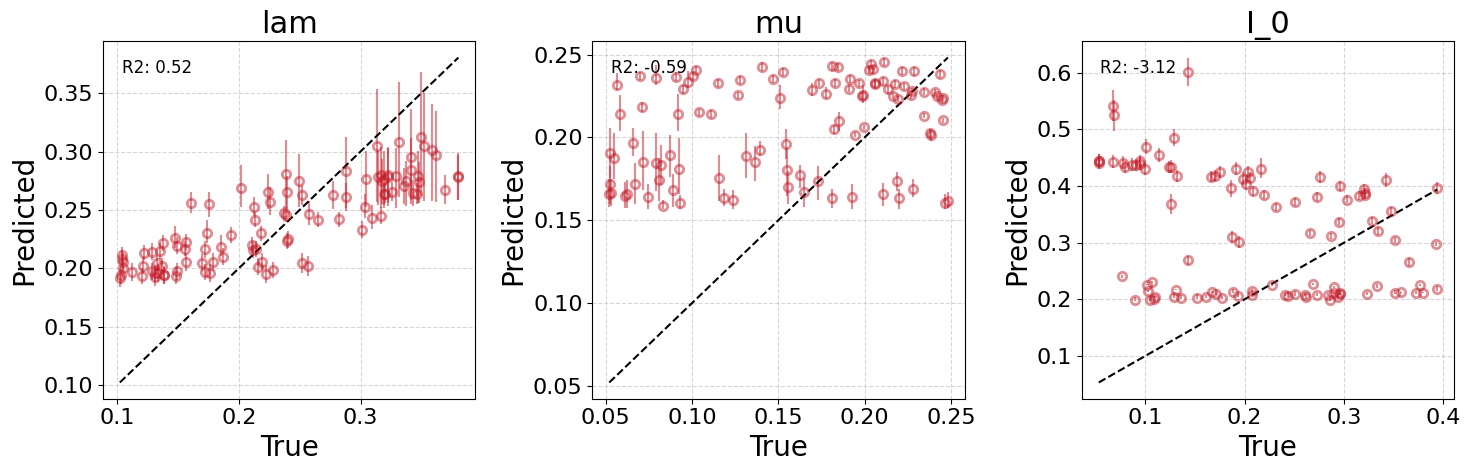

In [94]:
fig = plot_recovery_distribution(test_data['prior'][:100,:], test_data['posterior'][:100,:,:], labels=prior.get_labels())
#fig.axes[0].set_ylim(0, 1)
#fig.axes[1].set_ylim(0, 1)
#fig.axes[2].set_ylim(0, 1)
fig.tight_layout()

print(test_data['prior'][:5,:])
print(test_data['posterior'][:5,:,:])

After several attempts to get the network to work, we give up. We thought it would be worth the effort to catch up on the work from the previous exercise, but it's not. What we gather is that the network is not learning anything, and just outputting the mean value for the parameters.

In [52]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 
import seaborn as sns 
import torch 
import torch.nn as nn 
import torch.nn.functional as F 
from torch.utils.data import Dataset, DataLoader 
from sklearn.metrics import r2_score 
from tqdm import tqdm 
from scipy import stats 
from scipy.stats import binom, special_ortho_group, kstest, chi2 
import itertools

In [53]:
import warnings 
# Suppress future warnings 
warnings.simplefilter(action='ignore', category=FutureWarning) 
warnings.simplefilter(action='ignore', category=RuntimeWarning)

# Exercise 04a from generative neural networks

# [COPIED SAMPLE SOLUTION]

Simulation-based inference with invertible neural networks for epidemiology

## 1 Simulation set-up

In [54]:
N = 1000 
R_0 = 0 
T = 100

Implement the Euler forward solver for the SIR differential equations. We use analytical derivatives for the daily changes

In [55]:
def _deriv(input, N, lam, mu): 
    S, I, _ = input 
    dS = -lam * S * I / N 
    dI = lam * S * I / N - mu * I 
    dR = mu * I 
    return dS, dI, dR 
 
def simulate_sir_sample(lam, mu, I_0, T=T, N=N, R_0=R_0): 
    S, I, R = np.zeros(T), np.zeros(T), np.zeros(T) 
    dS, dI, dR = np.zeros(T), np.zeros(T), np.zeros(T) 
 
    # Initial conditions 
    S[0], I[0], R[0] = N - I_0 - R_0, I_0, R_0 
 
    for i in range(1, T): 
        dS[i], dI[i], dR[i] = _deriv((S[i-1], I[i-1], R[i-1]), N, lam, mu) 
        S[i], I[i], R[i] = S[i-1] + dS[i], I[i-1] + dI[i], R[i-1] + dR[i] 
 
    X = np.stack((dS, dR), axis=-1) 
    C = np.stack((S, I, R), axis=-1) 
 
    return X, C

First, we visualize an example simulation for $\lambda = 0.4$, $\mu = 0.2$ and  $I_0 = 1$. There is only a single infected person at the beginning!

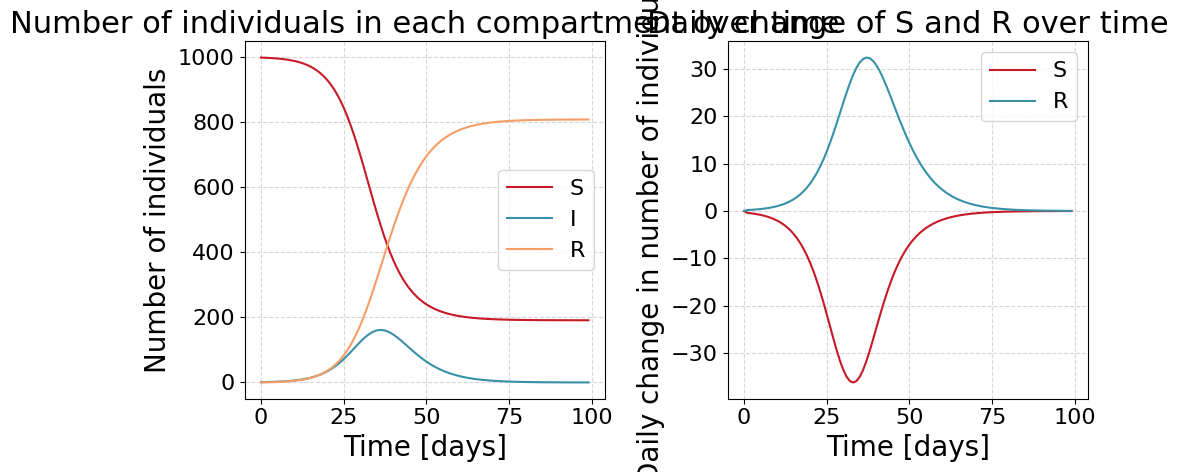

In [56]:
X, C = simulate_sir_sample(0.4, 0.2, 1) 
 
fig, ax = plt.subplots(1, 2, figsize=(10, 5)) 
 
ax[0].plot(C[:,0], label="S") 
ax[0].plot(C[:,1], label="I") 
ax[0].plot(C[:,2], label="R") 
ax[0].set_xlabel("Time [days]") 
ax[0].set_ylabel("Number of individuals") 
ax[0].set_title("Number of individuals in each compartment over time") 
ax[0].legend() 
 
ax[1].plot(X[:,0], label="S") 
ax[1].plot(X[:,1], label="R") 
ax[1].set_xlabel("Time [days]") 
ax[1].set_ylabel("Daily change in number of individuals") 
ax[1].set_title("Daily change of S and R over time") 
ax[1].legend() 
 
plt.tight_layout()

### Define prior ranges

In [57]:
lam_range = np.round(np.linspace(0, 1, 5), 1) 
mu_range = np.round(np.linspace(0, 1, 5), 1) 
I_0_range = [1, 10, 100, 500, 1000] 
 
t = np.arange(T) 
df_prior = [] 
for lam in lam_range: 
    for mu in mu_range: 
        for I0 in I_0_range: 
            sim, _ = simulate_sir_sample(lam, mu, I0) 
            sim_df = pd.DataFrame({'time': t, 'S': sim[:,0], 'R': sim[:,1]}) 
            sim_df['lambda'] = lam 
            sim_df['mu'] = mu 
            sim_df['I0'] = I0 
            df_prior.append(sim_df) 
 
df_prior = pd.concat(df_prior) 
df_prior = df_prior.melt(id_vars=['time', 'lambda', 'mu', 'I0'], value_vars=['S', 'R'], var_name='state', value_name='value')

In [58]:
#def get_color_label(row): 
#    return (row['state'], 'I0: ' + str(row['I0'])) 
 
#df_prior['label'] = df_prior.apply(get_color_label, axis=1) 
#g = sns.FacetGrid(df_prior, col="lambda", row="mu", hue="label", margin_titles=True, sharey=False) 
#g.map(plt.plot, "time", "value") 
#g.add_legend() 
#plt.show() 

In [59]:
# Prior distributions 
def prior_fn(n_samples: int = 1) -> np.array: 
    # use Gaussians with the mean in the middle of the interval and small standard deviations 
    lam = np.random.normal(0.55, 0.1, size=n_samples) 
    mu  = np.random.normal(0.45, 0.1, size=n_samples) 
    # use a Gamma distribution for I_0 with mean 20 and std about 14 
    I_0 = np.random.gamma(2, 10, size=n_samples) 
 
    # Since the standard deviations are small, we simply clip at the boundaries, 
    # although rejection sampling would be the statistically correct way of restricting the domains. 
    lam = np.clip(lam, 0.2, 0.9) 
    mu  = np.clip(mu, 0.1, 0.8) 
    I_0 = np.clip(I_0, 1, 100) 
  
    return np.stack((lam, mu, I_0), axis=-1)

In [60]:
# prior and simulation interfaces 
class Prior: 
    def __init__(self, prior_fn, labels): 
        self.prior_fn = prior_fn 
        self.labels = labels 
        self.mean = None 
        self.std = None 
        self.__set_stats__() 
     
    def __call__(self, n_samples, **kwargs): 
        return self.prior_fn(n_samples, **kwargs) 
     
    def get_labels(self): 
        return self.labels 
     
    def __set_stats__(self): 
        samples = self.prior_fn(10000) 
        self.mean = np.mean(samples, axis=0) 
        self.std = np.std(samples, axis=0) 
    
    def get_stats(self): 
        return self.mean, self.std 
    
class Simulator: 
    def __init__(self, simulator_fn, prior): 
        self.simulator_fn = simulator_fn 
        self.labels = ['dS', 'dR'] 
        self.C = ['S', 'I', 'R'] 
        self.mean = None 
        self.std = None 
        self.__set_stats__(prior(10000)) 
     
    def __call__(self, prior_samples, return_C=False): 
        X, C = np.zeros((prior_samples.shape[0], T, len(self.labels))), np.zeros((prior_samples.shape[0
], T, len(self.C))) 
        for i, p in enumerate(prior_samples): 
            X[i,...], C[i,...] = self.simulator_fn(*p) 
        if return_C: 
            return C 
        else: 
            return X 
     
    def get_labels(self): 
        return self.labels 
     
    def __set_stats__(self, prior_samples): 
        sim_samples = np.zeros((prior_samples.shape[0], T, len(self.labels))) 
        for i, p in enumerate(prior_samples): 
            sim_samples[i] = self.simulator_fn(*p)[0] 
        self.mean = np.mean(sim_samples, axis=0) 
        self.std = np.std(sim_samples, axis=0)     
     
    def get_stats(self): 
        return self.mean, self.std

Check that prior and simulator work as expected and generate outputs with the correct shapes

In [61]:
prior = Prior(prior_fn, ['lambda', 'mu', 'I_0']) 
mean, std = prior.get_stats() 
print(mean, std, "(exact values are [0.55, 0.45, 20] and [0.1, 0.1, 14])") 
 
simulator = Simulator(simulate_sir_sample, prior=prior) 
mean, std = simulator.get_stats() 
print(mean.shape, std.shape, simulator(prior(2)).shape)

[ 0.55067649  0.4489709  20.01617166] [ 0.09939568  0.10067593 14.11990973] (exact values are [0.55, 0.45, 20] and [0.1, 0.1, 14])
(100, 2) (100, 2) (2, 100, 2)


We finally wrap the simulator into convenience functions to generate torch-friendly training and test data for SBI. Note that the data are
standardized to zero mean and unit variance for better training performance.

In [62]:
class SIRDataset(Dataset): 
    def __init__(self, time_series_data, labels): 
        self.time_series_data = torch.tensor(time_series_data, dtype=torch.float32) 
        self.labels = torch.tensor(labels, dtype=torch.float32) 
 
    def __len__(self): 
        return len(self.time_series_data) 
 
    def __getitem__(self, idx): 
        return self.time_series_data[idx], self.labels[idx]
    
def generate_data(n_data_points, prior, simulator): 
    prior_mean, prior_std = prior.get_stats() 
    sim_mean, sim_std = simulator.get_stats() 
 
    prior_samples = prior(n_data_points) 
    norm_prior_samples = (prior_samples - prior_mean) / prior_std 
 
    sir_observations = simulator(prior_samples) 
    # convert to channels first 
    norm_sir_observations = (sir_observations - sim_mean) / sim_std 
    norm_sir_observations = np.nan_to_num(norm_sir_observations) 
    norm_sir_observations = np.moveaxis(norm_sir_observations, -1, 1) 
 
    return norm_prior_samples, norm_sir_observations 

def create_data_set(n_data_points, prior, simulator): 
    labels, data = generate_data(n_data_points, prior, simulator) 
    return SIRDataset(data, labels) 
 
def create_data_loader(n_data_points, prior, simulator, batch_size=512, shuffle=True): 
    dataset = create_data_set(n_data_points, prior, simulator) 
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle) 
 
def get_test_data(summary, inn, data_config, noise=0.0): 
    # first, again create test data 
    test_prior, test_sim = generate_data(data_config['n_test'], data_config['prior'], data_config['simulator']) 
    test_prior = test_prior + np.random.normal(0, noise, size=test_prior.shape) 
    prior_mean, prior_std = prior.get_stats() 
    unnorm_prior = test_prior * prior_std + prior_mean 
    sim_individuals = simulator(unnorm_prior, return_C=True) 
 
    summary.eval() 
    inn.eval() 
    conditions = summary(torch.tensor(test_sim, dtype=torch.float32)) 
    latents, _ = inn(torch.tensor(test_prior, dtype=torch.float32), conditions) 
    post_samples = np.zeros((data_config['n_test'], data_config['n_posterior_samples'], test_prior.shape[-1])) 
    for i in range(data_config['n_posterior_samples']): 
        z = torch.randn_like(latents) 
        post_samples[:,i,:] = inn(torch.tensor(z, dtype=torch.float32), conditions, inverse=True).detach().numpy() 
 
    prior_mean, prior_std = prior.get_stats() 
    unnorm_post_samples = post_samples * prior_std + prior_mean 
 
    return {'norm_prior': test_prior, 
            'norm_X': test_sim, 
            'norm_posterior': post_samples, 
            'prior': unnorm_prior, 
            'C': sim_individuals, 
            'posterior': unnorm_post_samples,
            'z': latents}

## 2 Parameter point estimation

We first design a convolutional network to estimate features and simulation parameters from the observations. The class  SummaryNN  is
designed such that it can be configured both as a point estimator (for direct regression of the hidden parameters) and as a summary network (for learning summary statistics for SBI)

In [63]:
class SummaryNN(nn.Module): 
    def __init__(self, conv_channel_sizes, feature_dim, 
                 dense_sizes, n_params_to_predict, last_layer = True, **kwargs): 
        super(SummaryNN, self).__init__() 
 
        dropout = kwargs.get('dropout', 0.0) 
        batch_norm = kwargs.get('batch_norm', False) 
        max_pool_size = kwargs.get('max_pool_size', None) 
        activation = kwargs.get('activation', nn.ReLU)         
 
        # Convolutional layers 
        num_conv_layers = len(conv_channel_sizes) 
        self.convs = nn.ModuleList() 
        for i in range(num_conv_layers): 
            in_channels = feature_dim if i == 0 else conv_channel_sizes[i-1] 
            out_channels = conv_channel_sizes[i] 
            if dropout > 0.0: 
                self.convs.append(nn.Dropout(dropout)) 
            self.convs.append(nn.Conv1d(in_channels, out_channels, kernel_size=3, stride=1, padding=1)) 
            self.convs.append(activation()) 
            if batch_norm: 
                self.convs.append(nn.BatchNorm1d(out_channels)) 
            if max_pool_size is not None: 
                self.convs.append(nn.MaxPool1d(kernel_size=max_pool_size, stride=max_pool_size)) 
 
        # Dense layers 
        example_input = torch.randn(1, feature_dim, T) 
        for conv in self.convs: 
            example_input = conv(example_input)

        self.dense = nn.ModuleList() 
        input_size = example_input.shape[1] * example_input.shape[2] 
        for i in range(len(dense_sizes)): 
            in_features = input_size if i == 0 else dense_sizes[i-1] 
            out_features = dense_sizes[i] 
            if dropout > 0.0: 
                self.dense.append(nn.Dropout(dropout)) 
            self.dense.append(nn.Linear(in_features, out_features)) 
            if i < len(dense_sizes) - 1 or last_layer: 
                self.dense.append(activation()) 
         
        if last_layer: 
            # bring to nr parameters to predict 
            self.dense.append(nn.Linear(dense_sizes[-1], n_params_to_predict)) 
 
    def forward(self, x): 
        for conv in self.convs: 
            x = conv(x) 
         
        x = x.flatten(1, -1) 
         
        for dense in self.dense: 
            x = dense(x) 
             
        return x

We put all options and defaults into config dictionaries.

In [64]:
train_config = { 
    'batch_size': 512, 
    'shuffle': True, 
    'training_steps': 10000, # istead of fixed epochs - to have the same nr of steps when varying n_samples & batch_size 
    'learning_rate': 0.0001, 
    'gradient_clipping': 1.0, 
    'weight_decay': 1e-4, 
    'loss_fn': nn.MSELoss(), 
    'device': "cuda" if torch.cuda.is_available() else "cpu" 
} 
 
summary_config = { 
    'conv_channel_sizes': [], 
    'dense_sizes': [512, 265], 
    'dropout': 0, 
    'batch_norm': False, 
    'activation': nn.ReLU, 
} 
 
data_config =  { 
    'n_samples': 5000, 
    'n_validation': 100, 
    'prior': prior, 
    'simulator': simulator, 
    'n_test': 1000, 
}

The following learning function configures  SummaryNN  as a point estimator by setting  n_params_to_predict  to the number of hidden
simulator parameters (3 in this case) and by regression against their ground-truth values with  train_config['loss_fn'] = 
MSELoss() .

In [65]:
def train(data_config, summary_config, train_config): 
    prior, simulator = data_config['prior'], data_config['simulator'] 
    data_samples = {'prior': prior(1), 'observations': simulator(prior(1))} 
    trainloader = create_data_loader(data_config['n_samples'], 
                                     prior, simulator, 
                                     batch_size=train_config['batch_size'], 
                                     shuffle=train_config['shuffle']) 
    validationloader = create_data_loader(data_config['n_validation'], 
                                          prior, simulator, 
                                          batch_size=train_config['batch_size'], 
                                          shuffle=train_config['shuffle']) 
 
    summary_net = SummaryNN(feature_dim=data_samples['observations'].shape[-1], 
                            n_params_to_predict=data_samples['prior'].shape[-1], 
                            **summary_config) 
 
    optimizer = torch.optim.Adam(summary_net.parameters(), 
                                 lr=train_config['learning_rate'], 
                                 weight_decay=train_config['weight_decay']) 
    loss_fn = train_config['loss_fn'] 
 
    loss_history = {'train': [], 'validation': []} 
 
    epochs = int(train_config['training_steps'] / len(trainloader)) 
    with tqdm(range(epochs)) as bar: 
        for _ in bar: 
            for _, (input, target) in enumerate(trainloader): 
                summary_net.train(True) 
                optimizer.zero_grad() 
                target_pred = summary_net(input) 
                loss = loss_fn(target_pred, target) 
                loss_history['train'].append(loss.item()) 
 
                loss.backward() 
                # Gradient clipping to prevent exploding gradients and unstable training 
                nn.utils.clip_grad_norm_(summary_net.parameters(), 
                                         max_norm=train_config['gradient_clipping']) 
                optimizer.step() 
 
                # include validation loss to detect overfitting 
                summary_net.eval() 
                with torch.no_grad(): 
                    for i, (vinput, vtarget) in enumerate(validationloader): 
                        v_pred = summary_net(vinput) 
                        vloss = loss_fn(v_pred, vtarget) 
                        loss_history['validation'].append(vloss.item()) 
            bar.set_postfix(loss=loss.item(), val_loss=vloss.item()) 
 
    return loss_history, summary_net

First, we train the model with different hyperparameters (network sizes and number of data samples):

In [66]:
range_n_samples = [#100, 
                   #1000, 
                   10000] 
net_sizes = [#[64, 64], 
             #[128, 128], 
             #[256, 256], 
             [512, 512]#, 
             #[1024, 1024]
             ] 
 
losses = [] 
models = [] 
for n_samples in range_n_samples: 
    data_config['n_samples'] = n_samples 
    for net_size in net_sizes: 
        summary_config['dense_sizes'] = net_size 
        print(f"Training with {n_samples} samples and net size {net_size}") 
        loss_history, summary_net = train(data_config, summary_config, train_config) 
        losses.append(loss_history['validation'][-1]) 
        models.append(summary_net) 
 
combinations = list(itertools.product(range_n_samples, net_sizes)) 
df_tuning = pd.DataFrame({'n_samples': [c[0] for c in combinations], 
                          'net_size': [c[1][0] for c in combinations], 'loss': losses}) 
df_tuning['model'] = models 
df_tuning['n_parameters'] = df_tuning['model'].apply(lambda x: sum(p.numel() for p in x.parameters() if p.requires_grad))

Training with 10000 samples and net size [512, 512]


100%|██████████| 500/500 [03:43<00:00,  2.23it/s, loss=0.0125, val_loss=0.00659] 


In [67]:
df_tuning

,n_samples,net_size,loss,model,n_parameters
0,10000,512,0.006585,SummaryNN(\n (convs): ModuleList()\n (dense)...,367107


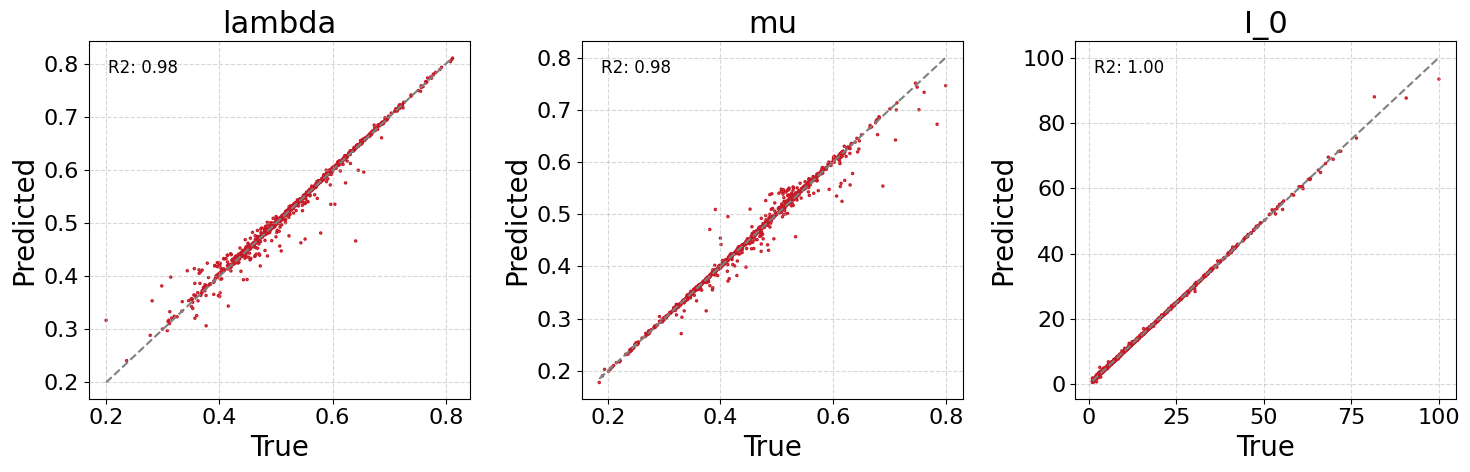

In [68]:
model = df_tuning.query('n_samples == 10000 & net_size == 512')['model'].tolist()[0] 
 
test_prior, test_sim = generate_data(data_config['n_test'], data_config['prior'], data_config['simulator']) 
model.eval() 
pred = model(torch.tensor(test_sim, dtype=torch.float32)).detach().numpy() 
 
labels = data_config['prior'].get_labels() 
 
def undo_normalization(data, mean, std): 
    return data * std + mean 
 
prior_mean, prior_std = prior.get_stats() 
test_prior = undo_normalization(test_prior, prior_mean, prior_std) 
pred = undo_normalization(pred, prior_mean, prior_std) 
 
fig, ax = plt.subplots(1, len(labels), figsize=(15, 5)) 
for i in range(3): 
    ax[i].scatter(test_prior[:,i], pred[:,i], s=1) 
    ax[i].plot([test_prior[:,i].min(), test_prior[:,i].max()],  
                [test_prior[:,i].min(), test_prior[:,i].max()],  
                '--', color='gray', label='Ideal Prediction') 
    ax[i].set_xlabel('True') 
    ax[i].set_ylabel('Predicted') 
    r2 = r2_score(test_prior[:,i], pred[:,i]) 
    ax[i].text(0.05, 0.95, f'R2: {r2:.2f}', transform=ax[i].transAxes, fontsize=12,  
                verticalalignment='top') 
    ax[i].set_title(f'{labels[i]}') 
 
plt.tight_layout() 
plt.show()

## 3 Parameter posterior distributions with INNs

The following implementation of a RealNVP performs two couplings in each coupling layer with the roles of the transformed and skip
dimensions exchanged. Only then do we apply a random rotation

In [69]:
 # set-up for the invertible network 
 
DEFAULT_SETTINGS_COUPLING = { 
        "dense_args": dict(layers=2, units=128, activation=nn.ReLU), 
        "dropout": True, 
        "dropout_prob": 0.05, 
        "soft_clamping": 0.7 
} 
 
# Nested scaling and shifting network (Conditioned) for the coupling blocks 
class DenseNet(nn.Module): 
    def __init__(self, dim_in, dim_out, dim_cond, settings, **kwargs): 
        super().__init__(**kwargs) 
 
        try: 
            activation = settings['activation'] 
            layers = settings['layers'] 
            units = settings['units'] 
        except: 
            raise ValueError("Please provide the settings for the dense network") 
 
        self.net = nn.ModuleList() 
        for l in range(layers): 
            self.net.add_module(f"Linear_{l}", nn.Linear(dim_in + dim_cond if l == 0 else units, units
)) 
            self.net.add_module(f"Activation_{l}", activation()) 
            if settings.get('batch_norm', False): 
                self.net.add_module(f"BatchNorm_{l}", nn.BatchNorm1d(units)) 
            if settings.get('dropout', False): 
                self.net.add_module(f"Dropout_{l}", nn.Dropout(settings.get('dropout_prob'))) 
         
        self.net.add_module(f"Linear_out", nn.Linear(units, dim_out)) 
     
    def forward(self, input, condition): 
        x = torch.cat([input, condition], dim=1) 
        for layer in self.net: 
            x = layer(x) 
        return x
    
# Affine Coupling Layer 
class AffineCoupling(nn.Module): 
    def __init__(self, dim_split_1, dim_split_2, coupling_settings, **kwargs): 
        super().__init__(**kwargs) 
 
        dense_settings = coupling_settings.get('dense_args', {}) 
        assert dense_settings != {}, "Please provide dense settings for the coupling layer" 
        assert coupling_settings.get('n_summary_stats') is not None, "Please provide the dimension of the condition as 'n_summary_stats'" 
        self.soft_clamp = coupling_settings.get('soft_clamping', None) 
 
        self.scale = DenseNet(dim_split_1, dim_split_2, coupling_settings['n_summary_stats'], dense_settings) 
        self.translate = DenseNet(dim_split_1, dim_split_2, coupling_settings['n_summary_stats'], dense_settings) 
 
    def forward(self, split1, split2, condition, inverse=False, **kwargs): 
        if not inverse: 
            return self._forward(split1, split2, condition, **kwargs) 
        else: 
            return self._inverse(split1, split2, condition, **kwargs) 
         
    def _forward(self, u1, u2, condition, **kwargs): 
        s = self.scale(u2, condition, **kwargs) 
        if self.soft_clamp is not None: 
            s = (2.0 * self.soft_clamp / torch.pi) * torch.atan(s / self.soft_clamp) 
        t = self.translate(u2, condition, **kwargs) 
        v = u1 * torch.exp(s) + t 
        log_det = torch.sum(s, dim=-1) 
        return v, log_det
    
    def _inverse(self, v1, v2, condition, **kwargs): 
        s = self.scale(v1, condition, **kwargs) 
        if self.soft_clamp is not None: 
            s = (2.0 * self.soft_clamp / torch.pi) * torch.atan(s / self.soft_clamp) 
        t = self.translate(v1, condition, **kwargs) 
        u = (v2 - t) * torch.exp(-s) 
        return u 
 
class CouplingLayer(nn.Module): 
    def __init__(self, 
                 latent_dim, 
                 has_rotation=True, 
                 coupling_settings: dict = {}, 
                 **kwargs): 
         
        super().__init__(**kwargs) 
        self.latent_dim = latent_dim 
        self.dim_out1 = latent_dim // 2 
        self.dim_out2 = latent_dim - self.dim_out1 
         
        merged_coupling_settings = DEFAULT_SETTINGS_COUPLING 
        for key, value in coupling_settings.items(): 
            merged_coupling_settings[key] = value 
         
        # Two-in-one coupling block (i.e., no inactive part after a forward pass) 
        self.net1 = AffineCoupling(self.dim_out2, self.dim_out1, 
                                   coupling_settings=merged_coupling_settings) 
        self.net2 = AffineCoupling(self.dim_out1, self.dim_out2, 
                                   coupling_settings=merged_coupling_settings) 
 
        self.rotation = torch.tensor(special_ortho_group.rvs(latent_dim) if has_rotation else torch.eye(latent_dim), 
                                     dtype=torch.float32) 

    def forward(self, inputs, condition, inverse=False, **kwargs): 
        if not inverse: 
            return self._forward(inputs, condition, **kwargs) 
        else: 
            return self._inverse(inputs, condition, **kwargs) 
     
    def _forward(self, inputs, condition, **kwargs): 
        log_det_tot = torch.zeros(1) 
 
        inputs = inputs @ self.rotation 
             
        # Pass through coupling layer 
        u1, u2 = torch.split(inputs, [self.dim_out1, self.dim_out2], dim=-1) 
        v1, log_det1 = self.net1(u1, u2, condition, **kwargs) 
        v2, log_det2 = self.net2(u2, v1, condition, **kwargs) 
        latent, log_det = torch.cat([v1, v2], dim=-1), log_det1 + log_det2 
        log_det += log_det_tot 
        return latent, log_det 
     
    def _inverse(self, latent, condition, **kwargs): 
        v1, v2 = torch.split(latent, [self.dim_out1, self.dim_out2], dim=-1) 
        u2 = self.net2(v1, v2, condition, inverse=True, **kwargs) 
        u1 = self.net1(u2, v1, condition, inverse=True, **kwargs) 
        inputs = torch.cat([u1, u2], dim=-1) 
 
        inputs = inputs @ self.rotation.T 
        return inputs
    
# Conditional Invertible neural network with affine or RealNVP coupling layers 
class ConditionalRealNVP(nn.Module): 
    def __init__(self, n_params, n_coupling_layers, coupling_settings={}, **kwargs): 
        super().__init__(**kwargs) 
 
        layer_settings = dict( 
            latent_dim=n_params) 
 
        self.coupling_layers = self._create_coupling_layers(n_coupling_layers, 
                                                            layer_settings, 
                                                            coupling_settings) 
 
    def forward(self, inputs, condition, inverse=False, **kwargs): 
        if not inverse: 
            return self._forward(inputs, condition, **kwargs) 
        else: 
            return self._inverse(inputs, condition, **kwargs) 
 
    def _forward(self, inputs, condition, **kwargs): 
        z = inputs 
        log_det_Js = torch.zeros(z.shape[0]) 
        for layer in self.coupling_layers: 
            z, log_det = layer(z, condition, **kwargs) 
            log_det_Js += log_det 
 
        return z, log_det_Js     
 
    def _inverse(self, inputs, condition, **kwargs): 
        z = inputs 
        for layer in reversed(self.coupling_layers): 
            z = layer(z, condition, inverse=True, **kwargs) 
        return z     
     
    def _create_coupling_layers(self, n_layers, layer_settings, coupling_settings): 
        return nn.ModuleList([CouplingLayer(**layer_settings, 
                                            has_rotation=k!=0, 
                                            coupling_settings=coupling_settings) 
                for k in range(n_layers)])

In [70]:
# loss functions 
def nll_loss_gaussian(z, log_det_J): 
    """ 
    Computes the Kullback-Leibler divergence between the true and approximate 
    posterior assuming a Gaussian latent space as a source distribution. 
    """ 
    loss = torch.mean(0.5 * torch.square(torch.norm(z, dim=-1)) - log_det_J) 
    return loss 
 
def kernel(X, Y, sigma, reduce_mean=True): 
    mat = X[:,None]-Y 
    mat = mat**2 
    mat = -mat/((float(sigma)**2) * 2) 
    mat = torch.exp(mat) 
    if reduce_mean: 
        mat = torch.mean(mat) 
    return mat 
 
def mmd(X, Y, sigma=[0.1, 0.5, 1, 2, 5]): 
    if isinstance(sigma, (int, float)): 
        return torch.sqrt(torch.abs(kernel(X, X, sigma) + kernel(Y, Y, sigma) - 2. * kernel(X, Y, sigma
))) 
    elif isinstance(sigma, list): 
        total_mmd = 0 
        for kernel_size in sigma: 
            total_mmd += mmd(X, Y, kernel_size) 
        return total_mmd 

We turn the point estimator network into a summary network by dropping the last layer

In [71]:
# training loop for inn 
def train_inn(data_config, summary_config, train_config, inn_config): 
    prior, simulator = data_config['prior'], data_config['simulator'] 
    data_samples = {'prior': prior(1), 'observations': simulator(prior(1))} 
    trainloader = create_data_loader(data_config['n_samples'], 
                                     prior, simulator, 
                                     batch_size=train_config['batch_size'], 
                                     shuffle=train_config['shuffle']) 
    validationloader = create_data_loader(data_config['n_validation'], 
                                          prior, simulator, 
                                          batch_size=train_config['batch_size'], 
                                          shuffle=train_config['shuffle']) 
 
    inference_network = ConditionalRealNVP(data_samples['prior'].shape[-1], 
                                           n_coupling_layers=inn_config['n_coupling_layers'], 
                                           coupling_settings=inn_config['coupling_settings']) 
    summary_network = SummaryNN(feature_dim=data_samples['observations'].shape[-1], 
                                n_params_to_predict=data_samples['prior'].shape[-1], 
                                last_layer=False, **summary_config) 
 
    optimizer = torch.optim.Adam(list(inference_network.parameters()) + list(summary_network.parameters()), 
                                 lr=train_config['learning_rate'], 
                                 weight_decay=train_config['weight_decay']) 
 
    loss_history = {'train': [], 'validation': []} 
    epochs = int(train_config['training_steps'] / len(trainloader)) 
    with tqdm(range(epochs)) as bar: 
        for _ in bar: 
            for i, (sim, params) in enumerate(trainloader): 
                summary_network.train(True) 
                inference_network.train(True) 
                optimizer.zero_grad() 
 
                sim, params = sim.to(train_config["device"]), params.to(train_config["device"]) 
                params_with_noise = params + torch.randn_like(params) * train_config['added_noise'] 
                summary_stats = summary_network(sim) 
                z, log_jacobians = inference_network(params_with_noise, summary_stats) 
                loss = nll_loss_gaussian(z, log_jacobians) 
                 
                if train_config.get('mmd_factor', 0.0) > 0.0: 
                    loss += mmd(summary_stats, torch.randn_like(summary_stats)) * train_config['mmd_factor']

                loss_history['train'].append(loss.item()) 
 
                loss.backward() 
                # Gradient clipping to prevent exploding gradients and unstable training 
                nn.utils.clip_grad_norm_(list(inference_network.parameters()) + list(summary_network.parameters()), 
                                         max_norm=train_config['gradient_clipping']) 
                optimizer.step() 
 
                # include validation loss to detect overfitting 
                summary_network.eval() 
                inference_network.eval() 
            with torch.no_grad(): 
                for i, (vsim, vparams) in enumerate(validationloader): 
                    vsim, vparams = vsim.to(train_config["device"]), vparams.to(train_config["device"]) 
                    vparams_with_noise = vparams + torch.randn_like(vparams) * train_config['added_noise'] 
                    vsummary_stats = summary_network(vsim) 
                    z, log_jacobians = inference_network(vparams_with_noise, vsummary_stats) 
                    vloss = nll_loss_gaussian(z, log_jacobians) 
                    if train_config.get('mmd_factor', 0.0) > 0.0: 
                        vloss += mmd(vsummary_stats, torch.randn_like(vsummary_stats)) * train_config['mmd_factor'] 
                    loss_history['validation'].append(vloss.item()) 
            bar.set_postfix(loss=loss.item(), val_loss=vloss.item()) 
         
    return loss_history, summary_network, inference_network

In [72]:
# network and training configs 
 
train_config = { 
    'batch_size': 512, 
    'shuffle': True, 
    'training_steps': 10000, # istead of fixed epochs - to have the same nr of steps when varying n_samples & batch_size 
    'learning_rate': 0.0001, 
    'gradient_clipping': 1.0, 
    'weight_decay': 1e-4, 
    'added_noise': 0.0,  # code is already prepared for exercise 4b, where we will add noise 
    'loss_fn': nll_loss_gaussian, 
    'mmd_factor': 0.0,  # by default, we impose no MMD regularization on the summary statistics 
    'device': "cuda" if torch.cuda.is_available() else "cpu" 
} 
 
summary_config = { 
    'conv_channel_sizes': [], 
    'dense_sizes': [512, 512], 
    'dropout': 0.0, 
    'batch_norm': False, 
    'activation': nn.ReLU, 
} 
 
inn_config = dict({ 
    'n_coupling_layers': 8, 
    'coupling_settings': { 
        'n_summary_stats': summary_config['dense_sizes'][-1], 
        "dense_args": dict(layers=2, units=128, activation=nn.ReLU), 
        "dropout": False, 
        "dropout_prob": 0.05 
    } 
})

data_config =  dict({ 
    'n_samples': 10000, 
    'n_validation': 100, 
    'prior': prior, 
    'simulator': simulator, 
    'n_test': 1000, 
    'n_posterior_samples': 100 
})

By adding an INN, we aim to learn the uncertainty in the parameters. For an inverse problem, there can be various sources of uncertainty: It will obviously arise when the simulation is stochastic, but we restrict ourselves to a deterministic simulation for now. Even then, the information loss in the mapping from parameters to observables can lead to parameter ambiguity. However, we observed in the point estimation experiments above that a regression network captures the parameters very well. Thus, we expect the uncertainty due to information loss and ambiguity to be small.

In [73]:
loss_history, summary_net, inn = train_inn(data_config, summary_config, train_config, inn_config)

/var/folders/dr/34chm7gn07vdb_w184vptt640000gn/T/ipykernel_78498/776171375.py:98: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.rotation = torch.tensor(special_ortho_group.rvs(latent_dim) if has_rotation else torch.eye(latent_dim),
100%|██████████| 500/500 [43:14<00:00,  5.19s/it, loss=-11.2, val_loss=-11]  


In [84]:
summary_net

SummaryNN(
  (layers): ModuleList(
    (0): Linear(in_features=200, out_features=512, bias=True)
    (1): Linear(in_features=512, out_features=512, bias=True)
  )
)

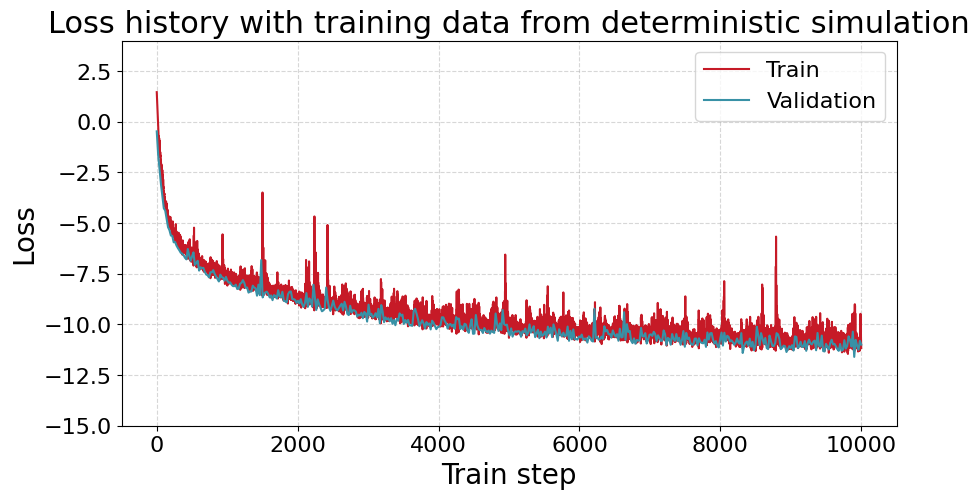

In [74]:
validation_point = np.linspace(0, len(loss_history['train']), len(loss_history['validation'])) 
 
plt.figure(figsize=(10, 5)) 
plt.plot(loss_history['train'], label='Train') 
plt.plot(validation_point,loss_history['validation'], label='Validation') 
 
plt.ylabel('Loss') 
plt.xlabel('Train step') 
plt.title(f'Loss history with training data from deterministic simulation') 
plt.ylim([-15, 4]) 
plt.legend() 
plt.show()

We again generate a test set of 1000 simulations from the prior and run the trained INN and summary network on it.

In [75]:
test_data = get_test_data(summary_net, inn, data_config=data_config, noise=0.0)

/var/folders/dr/34chm7gn07vdb_w184vptt640000gn/T/ipykernel_78498/4101823534.py:50: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  post_samples[:,i,:] = inn(torch.tensor(z, dtype=torch.float32), conditions, inverse=True).detach().numpy()


To compare the INN-based posterior estimates to the point estimates from above, we calculate the mean and 90% confidence bands from
the predicted posteriors and plot them against the ground-truth values.

In [76]:
plot_color = "#8f2727" 
 
def plot_recovery_distribution(prior_samples, posterior_samples, labels=None, agg_func=np.median): 
    # Calculate the mean and 90% confidence intervals of the posterior samples 
    estimates = agg_func(posterior_samples, axis=1) 
    percentile_5 = np.percentile(posterior_samples, 5, axis=1) 
    percentile_95 = np.percentile(posterior_samples, 95, axis=1) 
    n_prior_params = prior_samples.shape[1] 
    if labels is None: 
        labels = [f'Parameter {i+1}' for i in range(n_prior_params)] 
 
    fig, axes = plt.subplots(1, n_prior_params, figsize=(5 * n_prior_params, 5)) 
    if n_prior_params == 1: 
        axes = [axes]  # Ensure axes is iterable for a single parameter 
 
    for i in range(n_prior_params): 
        ax = axes[i] if n_prior_params > 1 else axes 
        # Error bars represent the 90% CI 
        yerr = [estimates[:, i] - percentile_5[:, i], percentile_95[:, i] - estimates[:, i]] 
        ax.errorbar(prior_samples[:, i], estimates[:, i], yerr=yerr, fmt='o', color=plot_color, alpha=
0.5) 
        ax.plot([prior_samples[:,i].min(), prior_samples[:,i].max()],  
            [prior_samples[:,i].min(), prior_samples[:,i].max()],  
            '--', color='black', label='Ideal Prediction') 
        r2 = r2_score(prior_samples[:,i], estimates[:,i]) 
        ax.text(0.05, 0.95, f'R2: {r2:.2f}', transform=ax.transAxes, fontsize=12,  
                    verticalalignment='top') 
        ax.set_title(f'{labels[i]}') 
        ax.set_xlabel('True') 
        ax.set_ylabel('Predicted') 
     
    return fig

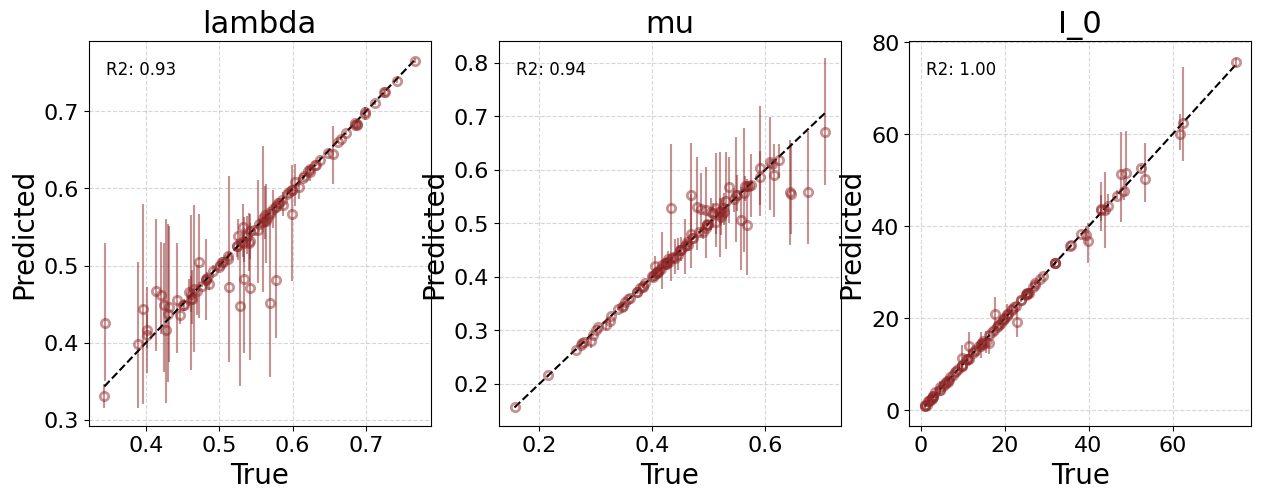

In [77]:
fig = plot_recovery_distribution(test_data['prior'][:100,:], 
                                 test_data['posterior'][:100,:,:], 
                                 labels=prior.get_labels())

We see larger errorbars and higher errors of the mean in the same regions where the point estimator struggles. Keep in mind that even with large error bars we can have a model that solves the inverse problem very well, e.g. when several parameter combinations lead to the same simulation outcome. We will check this later via 2D plots of the posteriors and resimulations.

### Evaluation of the posteriors on test data

We define a function to plot marginal and pair-wise posterior distributions along with the ground-truth parameters and the corresponding priors

In [35]:
def plot_posterior_distribution(ground_truth, posterior_estimates, prior_draws, labels): 
    n_params = len(labels) 
    df_posterior = pd.DataFrame(posterior_estimates, columns=labels) 
 
    g = sns.PairGrid(df_posterior) 
    g.map_diag(sns.histplot, fill=True, color='red', alpha=0.5, kde=True) 
    g.map_lower(sns.kdeplot, fill=True, color='red', alpha=0.5) 
 
    prior_draws_df = pd.DataFrame(prior_draws, columns=labels) 
    g.data = prior_draws_df 
    g.map_diag(sns.histplot, fill=True, color='lightgrey', alpha=0.5, kde=True, zorder=-1) 
    g.map_lower(sns.kdeplot, fill=True, color='lightgrey', alpha=0.5, zorder=-1) 
 
    for i, label in enumerate(labels): 
        g.axes[i, 0].set_ylabel(label) 
        g.axes[len(labels) - 1, i].set_xlabel(label) 
 
    # Add grids background 
    for i in range(n_params): 
        for j in range(n_params): 
            g.axes[i, j].grid(alpha=0.5) 
            if i != j and j < i: 
                g.axes[i, j].scatter(ground_truth[j], ground_truth[i], 
                                     marker='x', color='black', s=100, zorder=10) 
 
    for i, j in zip(*np.triu_indices_from(g.axes, 1)): 
        g.axes[i, j].axis("off") 
 
    g.tight_layout() 
    return g.figure 

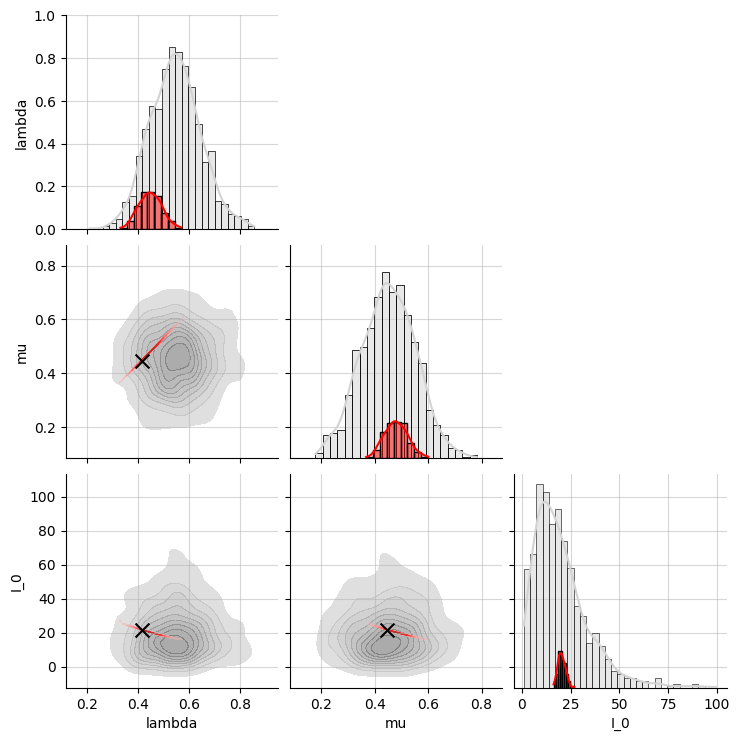

In [42]:
test_index = 6
fig = plot_posterior_distribution(test_data['prior'][test_index,...], 
                                  test_data['posterior'][test_index,...], 
                                  test_data['prior'], prior.get_labels())

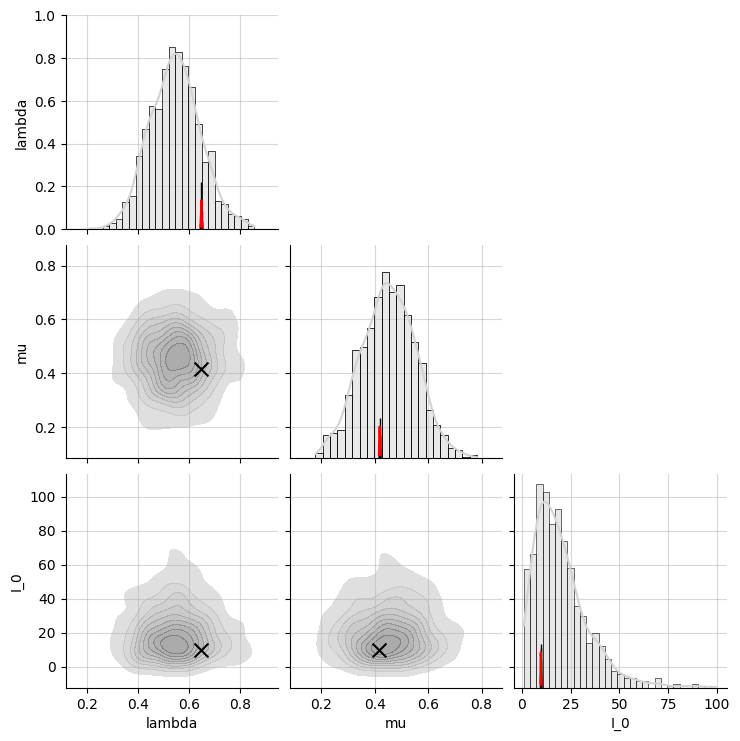

In [37]:
test_index = 0 
fig = plot_posterior_distribution(test_data['prior'][test_index,...], 
                                  test_data['posterior'][test_index,...], 
                                  test_data['prior'], prior.get_labels()) 

In [43]:
def plot_resimulations(unnorm_post_samples, total_numbers, n_observations, simulator): 
    for obs_idx in range(n_observations): 
        resimulations = simulator(unnorm_post_samples[obs_idx, :, :], return_C=True) 
 
        resim_means = resimulations.mean(axis=0) 
        resim_5 = np.percentile(resimulations, 5, axis=0) 
        resim_95 = np.percentile(resimulations, 95, axis=0) 
 
        plt.plot(total_numbers[obs_idx,:,0], label="S", color='blue') 
        plt.plot(total_numbers[obs_idx,:,2], label="R", color='green') 
        plt.plot(resim_means[:,0], label="S mean, 90% CI", color='lightblue', linestyle='--') 
        plt.plot(resim_means[:,2], label="R mean, 90% CI", color='lightgreen', linestyle='--') 
        plt.fill_between(np.arange(T), resim_5[:,0], resim_95[:,0], color='lightblue', alpha=0.3) 
        plt.fill_between(np.arange(T), resim_5[:,2], resim_95[:,2], color='lightgreen', alpha=0.3) 
 
        plt.xlabel("Time [days]") 
        plt.ylabel("Number of individuals") 
        plt.legend() 
        plt.show()

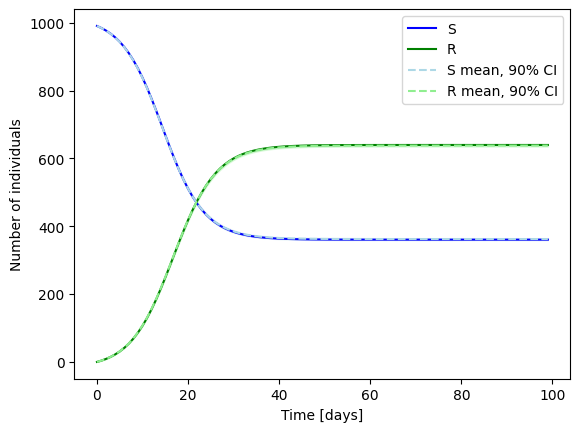

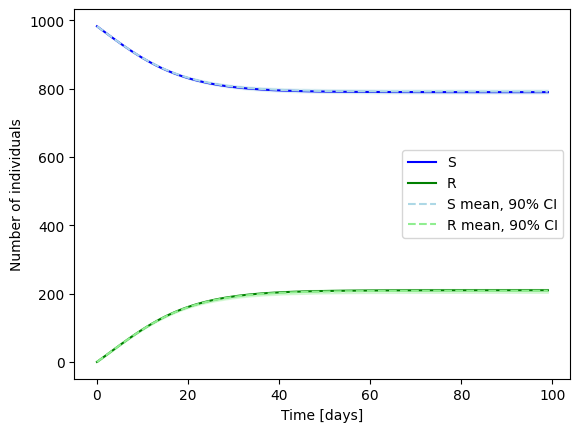

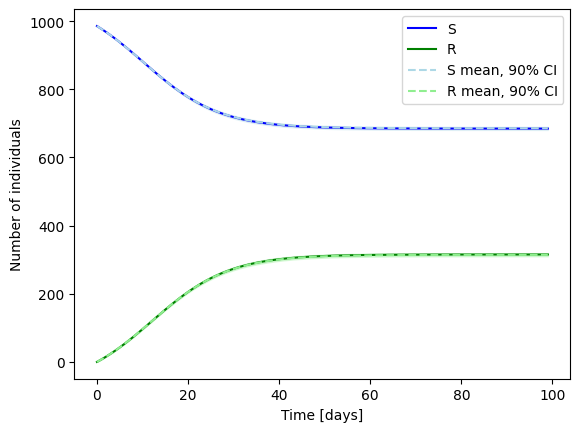

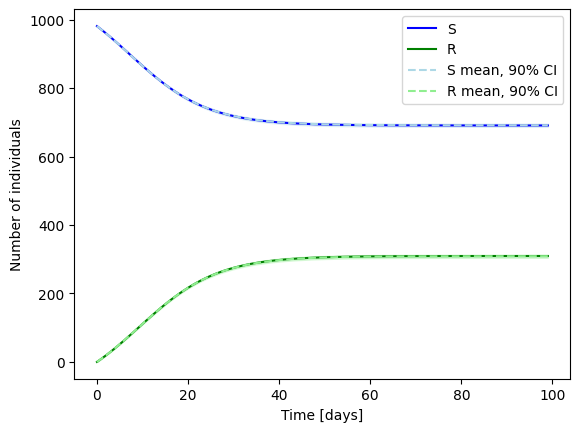

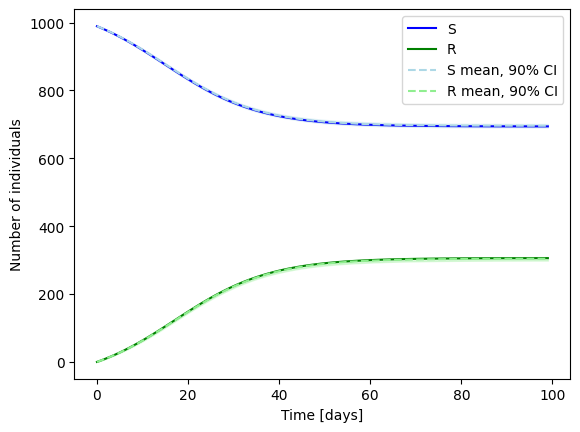

In [44]:
n_observations = 5 
n_resimulations = 100 
 
plot_resimulations(test_data['posterior'], test_data['C'], n_observations, data_config['simulator'])